# APP Forecasting_MKT_Integration

## 1. Importar bibliotecas e base de dados e tokens

### 1.1. Importar Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np
import datetime as dt
from datetime import datetime, timedelta

# Processamento de texto
import re    # Regular Expressions
import ast   # Abstract Syntax Tree (conversão de strings em estruturas Python)

# Visualização gráfica
import matplotlib.pyplot as plt

# Requisições HTTP / APIs
import requests

# Integração com Google Sheets
import gspread

# Machine Learning / Modelagem
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_poisson_deviance

# Serialização de modelos e objetos
import pickle
import joblib
import json
import openpyxl

# Sistema / manipulação de arquivos
import os

# Outros
import random
import holidays

Gerador de Token

https://developers.facebook.com/tools/explorer/

<details>
<summary>Descrição das métricas Meta Ads</summary>

## Meta Ads Metrics

- **account_id** – Identificador da conta de anúncios.
- **campaign_id** – Identificador único da campanha.
- **campaign_name** – Nome da campanha.
- **adset_id** – Identificador do conjunto de anúncios.
- **adset_name** – Nome do conjunto de anúncios.
- **ad_id** – Identificador do anúncio.
- **ad_name** – Nome do anúncio.

### Time

- **date_start** – Data inicial das métricas.
- **date_stop** – Data final das métricas.

### Delivery

- **impressions** – Número total de exibições do anúncio.
- **reach** – Número de pessoas únicas que viram o anúncio.
- **frequency** – Média de vezes que cada pessoa viu o anúncio.

### Cost

- **spend** – Valor total gasto na campanha.
- **cpc** – Custo médio por clique.
- **cpm** – Custo por mil impressões.
- **cpp** – Custo por pessoa alcançada.

### Clicks

- **clicks** – Total de cliques no anúncio.
- **unique_clicks** – Número de pessoas únicas que clicaram.
- **inline_link_clicks** – Cliques em links dentro do anúncio.
- **unique_inline_link_clicks** – Pessoas únicas que clicaram no link.

### Rates

- **ctr** – Taxa de cliques sobre impressões.
- **unique_ctr** – CTR considerando usuários únicos.
- **inline_link_click_ctr** – CTR específico para cliques no link.
- **unique_inline_link_click_ctr** – CTR de cliques únicos no link.

### Conversions

- **actions** – Lista de ações realizadas (ex: compras, leads).
- **action_values** – Valor monetário associado às ações.
- **cost_per_action_type** – Custo médio por tipo de ação.
- **conversions** – Número total de conversões.
- **conversion_values** – Valor total das conversões.

### Website Metrics

- **website_ctr** – CTR específico para tráfego ao site.
- **website_purchase_roas** – Retorno sobre gasto em compras no site.

### Outbound Traffic

- **outbound_clicks** – Cliques que levam para fora do Meta.
- **unique_outbound_clicks** – Usuários únicos que saíram para o site.

### Video

- **video_play_actions** – Número de vezes que o vídeo começou a ser reproduzido.
- **video_p25_watched_actions** – Visualizações até 25% do vídeo.
- **video_p50_watched_actions** – Visualizações até 50%.
- **video_p75_watched_actions** – Visualizações até 75%.
- **video_p100_watched_actions** – Visualizações completas.

- **video_avg_time_watched_actions** – Tempo médio assistido.
- **video_30_sec_watched_actions** – Visualizações com pelo menos 30 segundos.

### Brand Recall

- **estimated_ad_recall_rate** – Probabilidade estimada de lembrar do anúncio.
- **estimated_ad_recallers** – Número estimado de pessoas que lembrarão do anúncio.

### Quality Ranking

- **engagement_rate_ranking** – Classificação da taxa de engajamento.
- **quality_ranking** – Avaliação geral da qualidade do anúncio.
- **conversion_rate_ranking** – Classificação da taxa de conversão.

### 1.2. Importar tokens

In [73]:
# Improt tokens
with open("token.txt", "r") as f:
    TOKEN = f.read().strip()

with open("ad_account_id.txt", "r") as f:
    AD_ACCOUNT_ID = f.read().strip()

# print(TOKEN[:2])      # apenas para confirmar leitura
# print(AD_ACCOUNT_ID[:2])

### 1.3. Importar base de dados e lista de features

In [3]:
# import features
df_feature = pd.read_excel("feature_enginnering.xlsx")
df_feature = df_feature[df_feature["vai_usar_feature?"] == "sim"]
features = df_feature["nome_coluna"].tolist()

In [4]:
# Criar a variável url
# url = f"https://graph.facebook.com/v19.0/{AD_ACCOUNT_ID}/insights"

In [5]:
# # Parâmetros para busca no Meta
# params = {
#     "fields": """
#     campaign_id,
#     campaign_name,
#     impressions,
#     reach,
#     frequency,
#     clicks,
#     unique_clicks,
#     inline_link_clicks,
#     unique_inline_link_clicks,
#     spend,
#     cpc,
#     ctr,
#     cpm,
#     cpp,
#     actions,
#     action_values,
#     conversions,
#     conversion_values,
#     website_ctr,
#     website_purchase_roas,
#     cost_per_action_type,
#     cost_per_conversion,
#     objective,
#     optimization_goal,
#     date_start,
#     date_stop,
#     video_play_actions,
#     video_p25_watched_actions,
#     video_p50_watched_actions,
#     video_p75_watched_actions,
#     video_p100_watched_actions,
#     video_avg_time_watched_actions,
#     engagement_rate_ranking,
#     quality_ranking,
#     conversion_rate_ranking
#     """,
#     "level": "campaign",
#     "time_increment": 1,
#     "access_token": TOKEN
# }

In [6]:
# # definir ontem e config de parâmetros
# ontem = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")

# params["time_range"] = f'{{"since":"2025-06-25","until":"{ontem}"}}'
# params["time_increment"] = 1

In [7]:
# # Passar por todo o período de tempo definido nos parâmetros e trazer em valores diários
# all_data = []

# while True:
#     response = requests.get(url, params=params)
#     data = response.json()
    
#     if "data" in data:
#         all_data.extend(data["data"])
    
#     if "paging" in data and "next" in data["paging"]:
#         url = data["paging"]["next"]
#         params = {}
#     else:
#         break

# df = pd.DataFrame(all_data)

In [8]:
# print(data.get("paging"))

In [9]:
# # Salvar as informações paginadas em um arquivo csv
# df.to_csv("aline_cara_campaign_daily.csv", index=False)

In [10]:
# import da base de dados
df1 = pd.read_csv("aline_cara_campaign_daily_pt1.csv")
df2 = pd.read_csv("aline_cara_campaign_daily_pt2.csv")

df1["campaign_id"] = df1["campaign_id"].astype(str)
df2["campaign_id"] = df2["campaign_id"].astype(str)

df = pd.concat([df1, df2], ignore_index=True)

In [11]:
# # Salvar um df com campaign name e id
# campaign_lookup = (
#     df[["campaign_id", "campaign_name"]]
#     .drop_duplicates()
# )
# campaign_lookup = campaign_lookup.sort_values("campaign_name")

In [12]:
# df.head(3)

In [13]:
# # Pegando infos de campanhas ativas
# url_campaigns = f"https://graph.facebook.com/v19.0/{AD_ACCOUNT_ID}/campaigns"

# params_campaigns = {
#     "fields": "id,name,status",
#     "access_token": TOKEN
# }

# response_campaigns = requests.get(url_campaigns, params=params_campaigns)

# df_campaigns = pd.DataFrame(response_campaigns.json()["data"])

In [14]:
# Salvar df_campaigns em .csv
# df_campaigns.to_csv("df_campaigns.csv", index=False)

In [15]:
# Ler df_campaigns, aqui temos as campanhas ativas atualmnete no modelo
df_campaigns = pd.read_csv("df_campaigns.csv", dtype={"id": "object"})

### 1.4. Manipular colunas aninhadas em dicionários

In [16]:
# Extrair as colunas de purchase, actions_offsite_conversion_fb_pixel_add_to_cart e link_click
def extract_action(actions, action_type):
    if isinstance(actions, list):
        for a in actions:
            if a["action_type"] == action_type:
                return float(a["value"])
    return 0

df["purchases"] = df["actions"].apply(lambda x: extract_action(x, "purchase"))
df["add_to_cart"] = df["actions"].apply(lambda x: extract_action(x, "add_to_cart"))
df["link_clicks"] = df["actions"].apply(lambda x: extract_action(x, "link_click"))

In [17]:
# Join entre df e df_campaings afim de conseguir trabalhar com campanhas ativas e inativas de forma separada
df = df.merge(df_campaigns, left_on="campaign_id", right_on="id", how="left")

In [18]:
# Definir função sanitize_name
def sanitize_name(text):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", text).strip("_").lower()

In [19]:
# Definir função parse_nested_cell
def parse_nested_cell(x):
    if x is None:
        return None
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return None
        if x.startswith("[") and x.endswith("]"):
            try:
                return ast.literal_eval(x)
            except:
                return None
        return None
    if pd.isna(x):
        return None
    return None

In [20]:
# Desaninhando variáveis aninhadas
nested_cols = [
    "actions",
    "action_values",
    "website_ctr",
    "cost_per_action_type",
    "video_play_actions",
    "video_p25_watched_actions",
    "video_p50_watched_actions",
    "video_p75_watched_actions",
    "video_avg_time_watched_actions",
    "video_p100_watched_actions",
    "website_purchase_roas"
]

for col in nested_cols:
    df[col] = df[col].apply(parse_nested_cell)

new_columns = {}

for col in nested_cols:
    action_types = set()

    for cell in df[col].dropna():
        if isinstance(cell, list):
            for item in cell:
                if isinstance(item, dict) and "action_type" in item:
                    action_types.add(item["action_type"])

    for action in sorted(action_types):
        new_col = f"{col}_{sanitize_name(action)}"

        new_columns[new_col] = df[col].apply(
            lambda x: float(
                next(
                    (item["value"] for item in x
                     if isinstance(item, dict) and item.get("action_type") == action),
                    0
                )
            ) if isinstance(x, list) else 0
        )

# adiciona todas as colunas de uma vez
df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

In [21]:
df.shape

(1483, 150)

In [22]:
# list(df.columns)

In [23]:
# Trabalhando apenas com as colunas selecionadas em df_campaigns
df = df[[col for col in features if col in df.columns] + ['campaign_id' ,"campaign_name", "date_start"]]

In [24]:
df.shape

(1483, 24)

## 2. Início da modelagem estatística

### 2.1. Preparando a database

In [25]:
# Transformar 'date_start" em datetime
df['date_start'] = pd.to_datetime(df['date_start'])

In [26]:
# Organizar temporalmente a varia'vel 'date_start'
df = df.sort_values("date_start").reset_index(drop=True)

In [27]:
conversion_by_date = df.groupby("date_start")["actions_offsite_conversion_fb_pixel_add_to_cart"].sum()

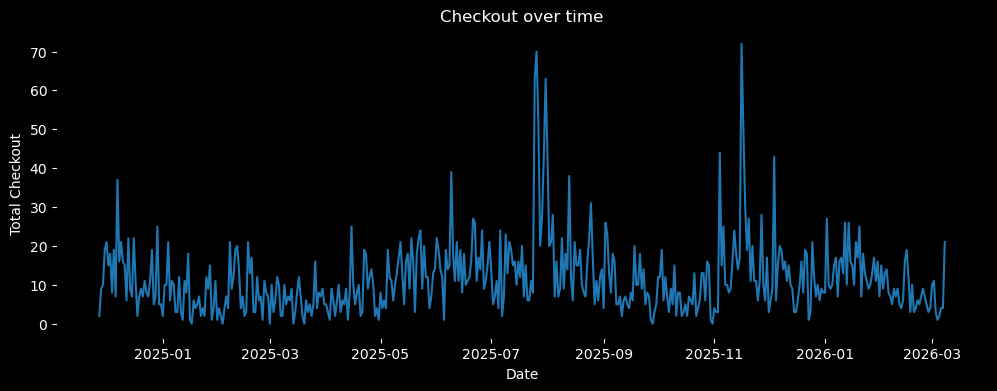

In [28]:
# Visão Gráfica de
plt.figure(figsize=(12,4), facecolor="black")

ax = plt.gca()
ax.set_facecolor("black")

plt.plot(conversion_by_date.index, conversion_by_date.values)

plt.title("Checkout over time", color="white")
plt.xlabel("Date", color="white")
plt.ylabel("Total Checkout", color="white")

plt.tick_params(colors="white")

plt.show()

### 2.2. Feature Engineering (time, lag)

In [29]:
# Creating time features
df["year"] = df["date_start"].dt.year
df["month"] = df["date_start"].dt.month
df["day"] = df["date_start"].dt.day
df["dayofweek"] = df["date_start"].dt.dayofweek
df["weekofyear"] = df["date_start"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date_start"].dt.quarter
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

In [30]:
# Variáveis defasadas
df["lag_1"] = df.groupby("campaign_id")["actions_offsite_conversion_fb_pixel_add_to_cart"].shift(1)
df["lag_7"] = df.groupby("campaign_id")["actions_offsite_conversion_fb_pixel_add_to_cart"].shift(7)
df["lag_14"] = df.groupby("campaign_id")["actions_offsite_conversion_fb_pixel_add_to_cart"].shift(14)
df["lag_28"] = df.groupby("campaign_id")["actions_offsite_conversion_fb_pixel_add_to_cart"].shift(28)

In [31]:
# Feriados
feriados_br = holidays.Brazil(years=[2024, 2025, 2026])
df["is_holiday"] = df["date_start"].dt.date.isin(feriados_br).astype(int)

In [32]:
# Transformando a coluna 'objective' em dummies
df = pd.get_dummies(df, columns=["objective"], drop_first=True)

In [33]:
# Variáveis derivadas
# As variáveis comentadas foram testadas e criaram ruído no modelo ou não trabalharam juntas em benefício do modelo

# df["lpv_per_click"] = np.where(
#     df["cost_per_action_type_link_click"] > 0,
#     df["cpc"] / df["cost_per_action_type_link_click"],
#     np.nan
# )

df["view_content_per_lpv"] = np.where(
    df["cost_per_action_type_omni_view_content"] > 0,
    df["cost_per_action_type_omni_landing_page_view"] / df["cost_per_action_type_omni_view_content"],
    np.nan
)

# df["wishlist_per_view_content"] = np.where(
#     df["cost_per_action_type_omni_add_to_wishlist"] > 0,
#     df["cost_per_action_type_omni_view_content"] / df["cost_per_action_type_omni_add_to_wishlist"],
#     np.nan
# )

# df["video_p25_rate"] = np.where(
#     df["video_play_actions_video_view"] > 0,
#     df["video_p25_watched_actions_video_view"] / df["video_play_actions_video_view"],
#     np.nan
# )

# df["video_p50_rate"] = np.where(
#     df["video_p25_watched_actions_video_view"] > 0,
#     df["video_p50_watched_actions_video_view"] / df["video_p25_watched_actions_video_view"],
#     np.nan
# )

# df["video_p75_rate"] = np.where(
#     df["video_p50_watched_actions_video_view"] > 0,
#     df["video_p75_watched_actions_video_view"] / df["video_p50_watched_actions_video_view"],
#     np.nan
# )

# df["video_p100_rate"] = np.where(
#     df["video_p75_watched_actions_video_view"] > 0,
#     df["video_p100_watched_actions_video_view"] / df["video_p75_watched_actions_video_view"],
#     np.nan
# )

df["video_p100_rate_lag1"] = (
    np.where(
        df["video_p75_watched_actions_video_view"] > 0,
        df["video_p100_watched_actions_video_view"] / df["video_p75_watched_actions_video_view"],
        np.nan
    )
)

df["video_p100_rate_lag1"] = (
    df.groupby("campaign_id")["video_p100_rate_lag1"].shift(1)
)

# df["video_p75_rate_lag1"] = (
#     df.groupby("campaign_id")["video_p75_watched_actions_video_view"].shift(1) /
#     df.groupby("campaign_id")["video_p50_watched_actions_video_view"].shift(1)
# )

# den_lag1 = df.groupby("campaign_id")["video_p50_watched_actions_video_view"].shift(1)

# df["video_p75_rate_lag1"] = np.where(
#     den_lag1 > 0,
#     df["video_p75_rate_lag1"],
#     np.nan
# )

### 2.3. Time-Based Split

In [34]:
# I used a one year training window to capture yearly seasonality patterns in the data.

split_date = "2026-01-01"

train_df = df[df["date_start"] < split_date]
valid_df = df[df["date_start"] >= split_date]

## 3. Criando o modelo

In [35]:
## 3.1. Definindo variáveis de treino

In [36]:
# Criando as variáveis X and y
features = [col for col in df.columns if col not in ["actions_offsite_conversion_fb_pixel_add_to_cart", "date_start", "campaign_id", "campaign_name"]]

X_train = train_df[features]
y_train = train_df["actions_offsite_conversion_fb_pixel_add_to_cart"]

X_valid = valid_df[features]
y_valid = valid_df["actions_offsite_conversion_fb_pixel_add_to_cart"]

In [37]:
# raise Exception("Parar execução aqui")

## 3.2 Otimização de Hyperparâmetros com optuna

In [38]:
# # Definindo os parâmetros de busca do modelo e treinando o modelo
# def objective(trial):

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

def objective(trial):
    params = {
        "objective": "poisson",
        "metric": "poisson",
        "verbosity": -1,
        "boosting_type": "gbdt",
        
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "num_leaves": trial.suggest_int("num_leaves", 8, 24),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 60),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.3),
    
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.85),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.85),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 5),
    
        "lambda_l1": trial.suggest_float("lambda_l1", 0.01, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.01, 10.0, log=True),
        
        "random_state": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
        "deterministic": True,
        "force_col_wise": True
    }

    model = lgb.LGBMRegressor(
        **params,
        n_estimators=300
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="poisson",
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_valid)
    preds = np.clip(preds, 1e-10, None)

    return mean_poisson_deviance(y_valid, preds)

sampler = optuna.samplers.TPESampler(seed=SEED)

In [39]:
# Executa a otimização de hiperparâmetros com Optuna.
study = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study.optimize(objective, n_trials=50)

[I 2026-03-11 17:59:03,357] A new study created in memory with name: no-name-d8725186-0dd2-4453-8011-b5d98369076f
[I 2026-03-11 17:59:05,118] Trial 0 finished with value: 2.083816741357872 and parameters: {'learning_rate': 0.04709342990753529, 'max_depth': 5, 'num_leaves': 20, 'min_child_samples': 44, 'min_split_gain': 0.04680559213273095, 'feature_fraction': 0.6389986300840507, 'bagging_fraction': 0.6145209030420499, 'bagging_freq': 5, 'lambda_l1': 0.6358358856676253, 'lambda_l2': 1.3311216080736887}. Best is trial 0 with value: 2.083816741357872.
[I 2026-03-11 17:59:05,260] Trial 1 finished with value: 2.0390574753732076 and parameters: {'learning_rate': 0.030752784807119137, 'max_depth': 5, 'num_leaves': 22, 'min_child_samples': 28, 'min_split_gain': 0.05454749016213018, 'feature_fraction': 0.6458511274633585, 'bagging_fraction': 0.6760605607398844, 'bagging_freq': 3, 'lambda_l1': 0.19762189340280073, 'lambda_l2': 0.07476312062252301}. Best is trial 1 with value: 2.0390574753732076.

In [40]:
# Salvar o melhores hyperparametros
best_params = study.best_params

with open("best_params.json", "w") as f:
    json.dump(best_params, f)

In [41]:
# # Importar os melhores hyperparametros
# import json

# with open("best_params.json", "r") as f:
#     best_params = json.load(f)

In [42]:
# best_params = study.best_params
# best_params

In [43]:
# Modelo de validação
# Este modelo é usado apenas para medir o desempenho em treino e validação,
# sem contaminar a avaliação com a base completa.
model_valid = lgb.LGBMRegressor(
    **best_params,
    objective="poisson",
    metric="poisson",
    n_estimators=1000,
    verbosity=-1,
    random_state=SEED,
    feature_fraction_seed=SEED,
    bagging_seed=SEED,
    data_random_seed=SEED,
    deterministic=True,
    force_col_wise=True
)

model_valid.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="poisson",
    callbacks=[lgb.early_stopping(20, verbose=False)]
);


In [44]:
# raise Exception("Parar execução aqui")

## 3.3. Treinando o modelo final com toda o período temporal

In [45]:
# Construindo as features para treinar o modelo com a base completa
features = [col for col in df.columns if col not in ["actions_offsite_conversion_fb_pixel_add_to_cart", "date_start", "campaign_id", "campaign_name" ]]

X = df[features]
y = df["actions_offsite_conversion_fb_pixel_add_to_cart"]

In [46]:
# Modelo final
# Este modelo é treinado na base completa e usado apenas para forecast.
model_final = lgb.LGBMRegressor(
    **best_params,
    objective="poisson",
    metric="poisson",
    n_estimators=1000,
    verbosity=-1,
    random_state=SEED,
    feature_fraction_seed=SEED,
    bagging_seed=SEED,
    data_random_seed=SEED,
    deterministic=True,
    force_col_wise=True
)

model_final.fit(X, y)


,boosting_type,'gbdt'
,num_leaves,14
,max_depth,5
,learning_rate,0.09984085198117315
,n_estimators,1000
,subsample_for_bin,200000
,objective,'poisson'
,class_weight,None
,min_split_gain,0.1710440737199273
,min_child_weight,0.001
,min_child_samples,20


In [47]:
# Salvar o modelo final e a ordem das features
joblib.dump(model_final, "modelo_forecast_meta_ads.pkl")
joblib.dump(df[features], "features_modelo_forecast_meta_ads.pkl")

['features_modelo_forecast_meta_ads.pkl']

### 3.4. Trabalhando em métricas do modelo

In [48]:
# Identificando previsões inválidas do modelo (≤ 0)
# Como estamos usando um modelo Poisson, as previsões deveriam ser estritamente positivas.
# Aqui verificamos quais linhas geraram previsões ≤ 0 para inspeção.

train_pred = model_valid.predict(X_train)

train_pred = np.clip(train_pred, 1e-10, None)

train_poisson = mean_poisson_deviance(y_train, train_pred)

print("Poisson Train:", train_poisson)

Poisson Train: 1.1070212205295276


In [49]:
train_pred[train_pred < 0].mean()

C:\Users\evert\AppData\Local\Temp\ipykernel_31608\3744419593.py:1: RuntimeWarning: Mean of empty slice
  train_pred[train_pred < 0].mean()
C:\Users\evert\anaconda3\envs\Data_Analyses\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

In [50]:
# Desempenho do modelo na fase de validação
valid_pred = model_valid.predict(X_valid)

valid_pred = np.clip(valid_pred, 1e-10, None)

valid_poisson = mean_poisson_deviance(y_valid, valid_pred)
print("Poisson Valid:", valid_poisson)


Poisson Valid: 1.922765360605439


In [51]:
# Célula antiga removida para evitar validação contaminada.
# A validação correta é feita apenas com model_valid.


In [52]:
# Comparativo dos modelos
results = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Poisson": [train_poisson, valid_poisson]
})

results

,Dataset,Poisson
0,Train,1.107021
1,Validation,1.922765


In [53]:
# baseline: modelo que prevê sempre a média do treino
baseline_pred = np.full_like(y_valid, y_train.mean(), dtype=float)

baseline_dev = mean_poisson_deviance(y_valid, baseline_pred)

# deviance do seu modelo
model_dev = valid_poisson

# pseudo R²
pseudo_r2 = 1 - (model_dev / baseline_dev)

print("Baseline deviance:", baseline_dev)
print("Model deviance:", model_dev)
print("Pseudo R²:", pseudo_r2)

Baseline deviance: 6.788390306034947
Model deviance: 1.922765360605439
Pseudo R²: 0.7167568047912506


In [54]:
# Quantas vezes cada variável foi usada para fazer divisões
# Quanto maior o valor, maior a importância da variável para distinção de grupos

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_valid.feature_importances_
}).sort_values("importance", ascending=False)

# Para ver as métricas na totalidade, libere a célula abaixo
# feature_importance

In [55]:
# feature_importance.to_excel("feature_importance.xlsx", index=False)

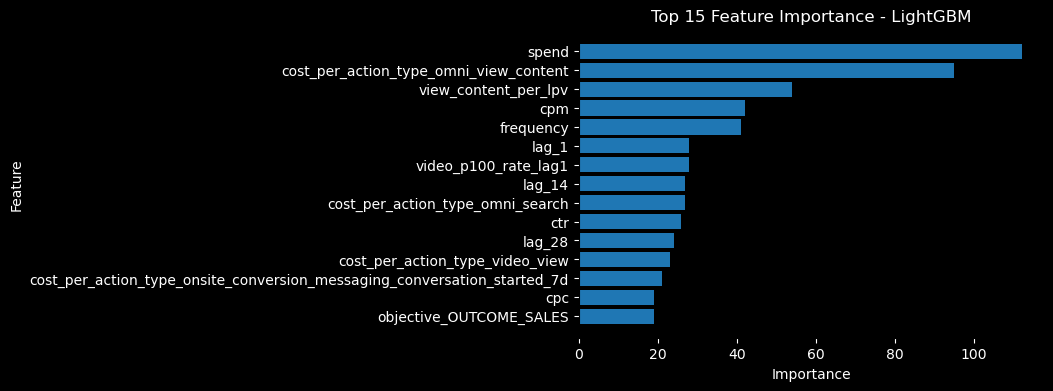

In [56]:
# Gráfico das variáveis mais importantes
top_features = feature_importance.head(15)

plt.figure(figsize=(6,4), facecolor="black")

ax = plt.gca()
ax.set_facecolor("black")

plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - LightGBM", color="white")
plt.xlabel("Importance", color="white")
plt.ylabel("Feature", color="white")

plt.tick_params(colors="white")

plt.show()

In [57]:
# raise Exception("Parar execução aqui")

## 4. Construção do desempenho das campanhas

### 4.1. Preparar a base de datas futuras

In [58]:
# Join em df e df_campaigns para termos campanhas estão ativas
df_active_campaigns = df.merge(
    df_campaigns[["id", "status", 'name']],
    left_on="campaign_id",
    right_on="id",
    how="left"
)

In [59]:
# Trabalhar apenas as campanhas ativas
df_active_campaigns = df_active_campaigns[df_active_campaigns['status'] == 'ACTIVE']

In [60]:
# Mostra as campanhas ativas na última data de df_active_campaigns
last_date = df_active_campaigns["date_start"].max()

# df_active_campaigns[df_active_campaigns['date_start'] == last_date]

In [61]:
# last_date

In [62]:
# df_active_sales_campaigns = df_active_campaigns[df_active_campaigns["objective_OUTCOME_SALES"] == 1]

In [63]:
# Gerar a listagem de datas para o restante do mês atual e do mês seguinte
start_forecast = last_date + pd.Timedelta(days=1)
end_forecast = last_date + pd.offsets.MonthEnd(2)

forecast_dates = pd.date_range(
    start=start_forecast,
    end=end_forecast,
    freq="D"
)

In [64]:
# Base necessária para gerar o futuro de nossas campanhas
df_forecast = pd.DataFrame({
    "date_start": forecast_dates
})

df_forecast = df_forecast.merge(
    df_active_campaigns[["campaign_id", "campaign_name"]].drop_duplicates(),
    how="cross"
)

Adicionando as variáveis de tempo ao df_forecast

In [65]:
# Adicionar variáveis temporais
df_forecast["year"] = df_forecast["date_start"].dt.year
df_forecast["month"] = df_forecast["date_start"].dt.month
df_forecast["day"] = df_forecast["date_start"].dt.day
df_forecast["dayofweek"] = df_forecast["date_start"].dt.dayofweek
df_forecast["weekofyear"] = df_forecast["date_start"].dt.isocalendar().week.astype(int)
df_forecast["quarter"] = df_forecast["date_start"].dt.quarter
df_forecast["is_weekend"] = df_forecast["dayofweek"].isin([5,6]).astype(int)

Adicionando as variávesi defasadas

In [66]:
# Adicionar variáveis defasadas
last_values = (
    df
    .sort_values("date_start")
    .groupby("campaign_id")
    .tail(28)
)

lags = (
    last_values
    .sort_values(["campaign_id","date_start"])
    .groupby("campaign_id")["actions_offsite_conversion_fb_pixel_add_to_cart"]
    .agg(
        lag_1=lambda x: x.iloc[-1],
        lag_7=lambda x: x.iloc[-7] if len(x) >= 7 else None,
        lag_14=lambda x: x.iloc[-14] if len(x) >= 14 else None,
        lag_28=lambda x: x.iloc[-28] if len(x) >= 28 else None
    )
    .reset_index()
)

df_forecast = df_forecast.merge(
    lags,
    on="campaign_id",
    how="left"
)

Adicionando as demais variáveis como a média dos últimos 7 dias da última data de df

In [67]:
# Pesquisa as colunas que ainda não estão em df_forecast
features = X.columns
missing_cols = [col for col in features if col not in df_forecast.columns]

In [68]:
# Cria a variável cols
cols = [
    c for c in missing_cols
    if c in df.columns and c not in ["campaign_id", "date_start", "campaign_name"]
]

In [69]:
# Cria uma variável que trabalha com os últimos 7 dias da última data disponível em df
last_7 = (
    df
    .sort_values("date_start")
    .groupby("campaign_id")
    .tail(7)
)

In [70]:
# Cria uma variável que faz a média dos últimos 7 dias de uma variável
means_7 = (
    last_7
    .groupby("campaign_id")[cols]
    .mean()
    .reset_index()
)

In [71]:
# Adiciona as informações com join através do cruzamento de campaign_id
df_forecast = df_forecast.merge(
    means_7,
    on="campaign_id",
    how="left"
)

In [72]:
# df_forecast.columns

In [73]:
# Verificação rápida da estrutura do forecast
print(df_forecast.shape)
print(len(df_forecast.columns))


(424, 39)
39


### 4.2. Rodar o modelo em cima de df_forecast

In [74]:
X_forecast = df_forecast[X.columns]

In [75]:
df_forecast["prediction"] = model_final.predict(X_forecast)

In [76]:
forecast_month_mean = (
    df_forecast
    .groupby("campaign_name")
    .agg({
        "prediction": "sum",
        "spend": "sum"
    })
    .reset_index()
)

forecast_month_mean["prediction_per_spend"] = np.where(
    forecast_month_mean["spend"] > 0,
    forecast_month_mean["prediction"] / forecast_month_mean["spend"],
    np.nan
)

forecast_month_mean = forecast_month_mean.sort_values(
    "prediction_per_spend",
    ascending=False
)

In [77]:
forecast_month_mean

,campaign_name,prediction,spend,prediction_per_spend
6,[VENDAS] - OnGoing - 08/02,29.772650,612.301429,0.048624
7,[VENDAS] - OnGoing - Consumidor,42.806801,1080.064286,0.039634
5,[VENDAS] - ANALISE#1 - Conjuntos,22.176394,651.521429,0.034038
4,[PERFIL] - TRÁFEGO - OnGoing - Posts,14.216033,493.430000,0.028811
1,Publicação do Instagram: Provador AC \nConjunt...,3.510932,309.822857,0.011332
2,Publicação do Instagram: Reposição às 10h em...,1.644544,306.264286,0.005370
3,[MENSAGEM] - OnGoing - Bag,2.027347,585.120000,0.003465
0,Publicação do Instagram: Conjunto Lilly✨...,1.410936,657.502857,0.002146


In [78]:
# df_forecast.to_excel("df_forecast.xlsx", index=False)